In [520]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from tqdm import tqdm

## XOR Network

Rete con hidden size = 2 → **9 parametri totali** (W1:4, b1:2, W2:2, b2:1).
Questo è lo spazio su cui campioneremo col flow.

In [521]:
# Input XOR
X = jnp.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = jnp.array([[0.], [1.], [1.], [0.]])

HIDDEN = 2          # hidden size → 9 params totali
D_PARAMS = 9        # dimensione spazio parametri

In [522]:
def init_net_params(key):
    k1, k2 = jax.random.split(key)
    return {
        "W1": jax.random.normal(k1, (2, HIDDEN)),   # 4 params
        "b1": jnp.zeros((HIDDEN,)),                        # 2 params
        "W2": jax.random.normal(k2, (HIDDEN, 1)),   # 2 params
        "b2": jnp.zeros((1,))                              # 1 param
    }                                                       # tot: 9

def net(params, x):
    h = jnp.tanh(x @ params["W1"] + params["b1"])
    return jax.nn.sigmoid(h @ params["W2"] + params["b2"])

def loss_fn(params, X, y):
    preds = net(params, X)
    eps = 1e-7
    return -jnp.mean(y * jnp.log(preds + eps) + (1 - y) * jnp.log(1 - preds + eps))

# ── Flatten / Unflatten ──────────────────────────────────────────────────────
def flatten_params(p):
    """Dict → vettore piatto di dim 9."""
    return jnp.concatenate([
        p["W1"].ravel(),   # [0:4]
        p["b1"].ravel(),   # [4:6]
        p["W2"].ravel(),   # [6:8]
        p["b2"].ravel()    # [8:9]
    ])

def unflatten_params(flat):
    """Vettore piatto di dim 9 → dict."""
    return {
        "W1": flat[0:4].reshape(2, HIDDEN),
        "b1": flat[4:6],
        "W2": flat[6:8].reshape(HIDDEN, 1),
        "b2": flat[8:9]
    }

## Distribuzione target

Trattando la loss come energia, la distribuzione di Boltzmann sui parametri è:

$$p(\theta | \mathcal{D}) \propto e^{-\mathcal{L}(\theta, \mathcal{D}) / T}$$

con $T$ temperatura che controlla la "larghezza" della distribuzione.


Per ora kbT fissato da noi, piccolo per avere buoni parametri

In [523]:
kbT = 10e-4  # kbT → distribuzione molto concentrata sui minimi
def log_pz(z):
    """Log-prob della base distribution N(0,I), shape (batch,)."""
    return -0.5 * jnp.sum(z**2, axis=1)

def log_q_target(k_flat, X, y):
    """Log-prob target su un singolo campione di parametri (vettore 9D)."""
    net_params = unflatten_params(k_flat)
    return -loss_fn(net_params, X, y)/kbT  # kbT → distribuzione molto concentrata sui minimi

## Normalizing Flow — Real NVP

Architettura: **3 coupling layers con permutazioni** (Real NVP, Dinh et al. 2017).

Ogni coupling layer suddivide il vettore in due metà:
- **metà fissa** $z_1$ → passa invariata
- **metà trasformata** $z_2 \to z_2' = z_2 \odot e^{s(z_1)} + t(z_1)$

Il log-det-Jacobiano è $\sum_i s_i(z_1)$ — calcolabile esattamente!

La loss è il **KL inverso** (variational inference):
$$\mathcal{L}_{\text{flow}} = \mathbb{E}_{z \sim \mathcal{N}}\left[\log p_z(z) - \log|\det J| - \log \tilde{p}(f(z))\right]$$

In [524]:
# ── MLP helper ──────────────────────────────────────────────────────────────
FLOW_HIDDEN = 32

def init_mlp(key, in_dim, out_dim, hidden=FLOW_HIDDEN):
    k1, k2 = jax.random.split(key)
    return {
        "W1": 0.1 * jax.random.normal(k1, (in_dim, hidden)),
        "b1": jnp.zeros(hidden),
        # W2 inizializzato a zero → inizialmente s=0, t=0 (identità)
        "W2": 0.1 * jax.random.normal(k2, (hidden, out_dim)),
        "b2": jnp.zeros(out_dim),
    }

def apply_mlp(p, x):
    h = jnp.tanh(x @ p["W1"] + p["b1"])
    return h @ p["W2"] + p["b2"]

# ── Flow params init ─────────────────────────────────────────────────────────
# Split dello spazio D=9:
#   coupling 1,3 : fissa [:4], trasforma [4:] → net 4→5
#   coupling 2   : (dopo permute) fissa [:5], trasforma [5:] → net 5→4
#  coupling 4,6 : (dopo permute) fissa [:5], trasforma [5:] → net 5→4
#  coupling 5,7 : (dopo permute) fissa [:4], trasforma [4:] → net 4→5
#  coupling 8   : (dopo permute) fissa [:5], trasforma [5:] → net 5→4

def init_flow_params(key):
    keys = jax.random.split(key, 16)
    return {
        "c1_s": init_mlp(keys[0], 4, 5),
        "c1_t": init_mlp(keys[1], 4, 5),
        "c2_s": init_mlp(keys[2], 5, 4),
        "c2_t": init_mlp(keys[3], 5, 4),
        "c3_s": init_mlp(keys[4], 4, 5),
        "c3_t": init_mlp(keys[5], 4, 5),
        "c4_s": init_mlp(keys[6], 5, 4),
        "c4_t": init_mlp(keys[7], 5, 4),
        "c5_s": init_mlp(keys[8], 4, 5),
        "c5_t": init_mlp(keys[9], 4, 5),
        "c6_s": init_mlp(keys[10], 5, 4),
        "c6_t": init_mlp(keys[11], 5, 4),
        "c7_s": init_mlp(keys[12], 4, 5),
        "c7_t": init_mlp(keys[13], 4, 5),
        "c8_s": init_mlp(keys[14], 5, 4),
        "c8_t": init_mlp(keys[15], 5, 4),
    }

In [525]:
def permute(k):
    """Inverte l'ordine delle dimensioni → alterna quale metà viene trasformata."""
    return k[:, ::-1]

def coupling_layer(s_params, t_params, z, split, sin_state=False):
    """
    Real NVP coupling layer.
    z[:, :split]  → fissa
    z[:, split:]  → trasformata con s,t condizionati sulla parte fissa
    """
    z1, z2 = z[:, :split], z[:, split:]
    s = apply_mlp(s_params, z1)         # (batch, D-split)
    s = jnp.clip(s, -5.0, 5.0)
    t = apply_mlp(t_params, z1)          # (batch, D-split)
    if sin_state:
        t = 2*jnp.sin(t)
    z2_new = z2 * jnp.exp(s) + t
    log_det = jnp.sum(s, axis=1)         # (batch,)
    return jnp.concatenate([z1, z2_new], axis=1), log_det

def forward(flow_params, z):
    """
    z (base, N(0,I))  →  k (spazio parametri)
    Restituisce k e log|det J| accumulato.
    """
    # Layer 1: fissa [:4], trasforma [4:]
    k, ld1 = coupling_layer(flow_params["c1_s"], flow_params["c1_t"], z, split=4)
    k = permute(k)
    ld = ld1
    # Layer 2: (dopo flip) fissa [:5], trasforma [5:]
    k, ld2 = coupling_layer(flow_params["c2_s"], flow_params["c2_t"], k, split=5)
    ld += ld2
    k = permute(k)
    # Layer 3: fissa [:4], trasforma [4:]
    k, ld3 = coupling_layer(flow_params["c3_s"], flow_params["c3_t"], k, split=4, sin_state=True)
    ld += ld3
    k = permute(k)
    k, ld4 = coupling_layer(flow_params["c4_s"], flow_params["c4_t"], k, split=5, sin_state=True)
    ld += ld4
    k = permute(k)
    k, ld5 = coupling_layer(flow_params["c5_s"], flow_params["c5_t"], k, split=4, sin_state=True)
    ld += ld5
    k = permute(k)
    k, ld6 = coupling_layer(flow_params["c6_s"], flow_params["c6_t"], k, split=5, sin_state=True)
    ld += ld6
    k = permute(k)
    k, ld7 = coupling_layer(flow_params["c7_s"], flow_params["c7_t"], k, split=4)
    ld += ld7
    k = permute(k)
    k, ld8 = coupling_layer(flow_params["c8_s"], flow_params["c8_t"], k, split=5)
    ld += ld8
    k = permute(k)
    return k, ld

In [526]:
def flow_loss(flow_params, key, n_samples):
    """
    KL inverso:  E_{z~p_z} [ log p_z(z)  -  log|det J|  -  log π(f(z)) ]
    
    dove π(k) ∝ exp(-loss(k)/T) è la distribuzione target (Boltzmann).
    Minimizzare questa quantità = avvicinare q_φ a π.
    """
    z = jax.random.normal(key, (n_samples, D_PARAMS))
    k, log_det = forward(flow_params, z)

    log_p   = log_pz(z)                                                     # (n,)
    log_q   = jax.vmap(lambda ki: log_q_target(ki, X, y))(k)            # (n,)

    return jnp.mean(log_p - log_det - log_q)

In [527]:
@jax.jit
def step(flow_params, opt_state, key, n_samples=1000):
    l, grads = jax.value_and_grad(flow_loss)(flow_params, key, n_samples=n_samples)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(flow_params, updates)
    return new_params, new_opt_state, l

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:59<00:00, 168.58it/s]


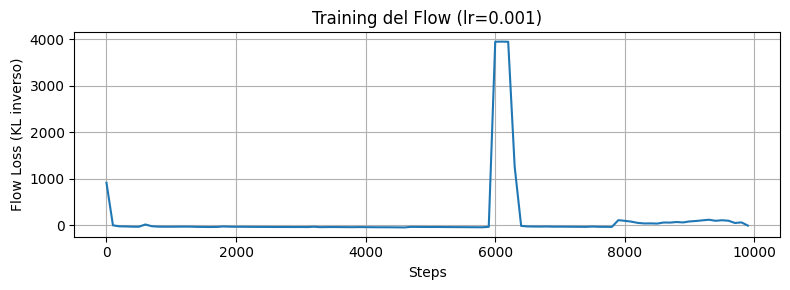

In [528]:
key = jax.random.PRNGKey(42)
key, subkey = jax.random.split(key)
flow_params = init_flow_params(subkey)

lr = 1e-3
optimizer = optax.adam(lr)
opt_state = optimizer.init(flow_params)

n_steps = 10000
losses_flow = []

for i in tqdm(range(n_steps)):
    key, subkey = jax.random.split(key)
    flow_params, opt_state, l = step(flow_params, opt_state, subkey)
    if i % 100 == 0:
        losses_flow.append(float(l))

plt.figure(figsize=(8, 3))
plt.plot(range(0, n_steps, 100), losses_flow)
plt.xlabel('Steps')
plt.ylabel('Flow Loss (KL inverso)')
plt.title(f'Training del Flow (lr={lr})')
plt.grid(True)
plt.tight_layout()
plt.show()

## Ensemble — campionamento di reti

Il flow ha imparato $q_\phi(\theta) \approx p(\theta|\mathcal{D})$.
Ora campioniamo N reti e facciamo **predizioni d'ensemble** con incertezza.

In [554]:
key, subkey = jax.random.split(key)
n_samples = 10000
z = jax.random.normal(subkey, (n_samples, D_PARAMS))
k_samples, log_det = forward(flow_params, z)

# Predizioni ensemble: vmap su tutti i campioni di parametri
preds_all = jax.vmap(lambda k: net(unflatten_params(k), X))(k_samples)  # (n_samples, 4, 1)
preds_all = preds_all.squeeze(-1)   # (n_samples, 4)

mean_pred = preds_all.mean(axis=0)  # (4,)
std_pred  = preds_all.std(axis=0)   # (4,)

labels = ["(0,0)→0", "(0,1)→1", "(1,0)→1", "(1,1)→0"]

print("\nEnsemble predictions (media ± std):")
for i, lab in enumerate(labels):
    print(f"  {lab}  →  {mean_pred[i]:.6f} ± {std_pred[i]:.6f}")


Ensemble predictions (media ± std):
  (0,0)→0  →  0.001616 ± 0.028809
  (0,1)→1  →  0.993346 ± 0.057459
  (1,0)→1  →  0.972641 ± 0.111838
  (1,1)→0  →  0.032886 ± 0.128458


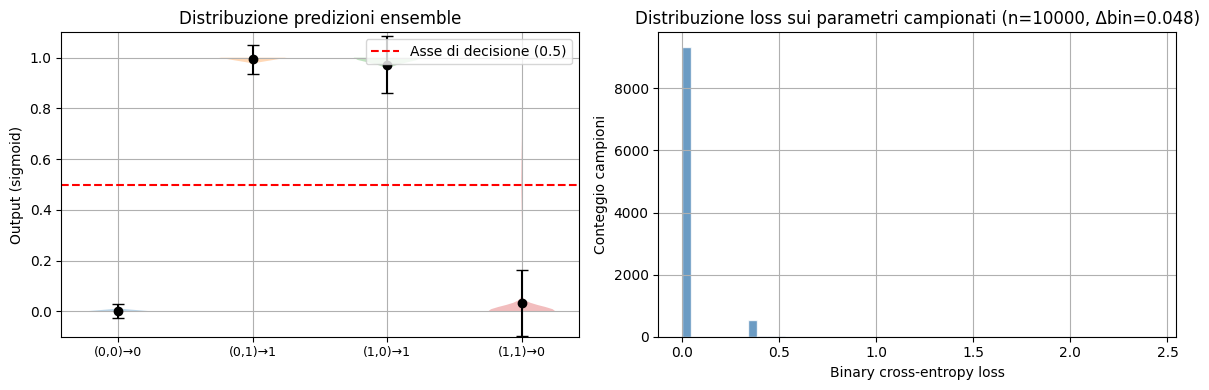


Loss media campionata:  0.0252
Loss minima campionata: -0.0000
% campioni con loss < 0.1: 93.4%


In [555]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: distribuzione predizioni per ogni input XOR ---
ax = axes[0]

for i, lab in enumerate(labels):
    # distribuzione
    ax.violinplot(
    preds_all[:, i],
    positions=[i],
    showmeans=False,
    showmedians=False,
    showextrema=False,
)

    mean = preds_all[:, i].mean()
    std = preds_all[:, i].std()

    ax.errorbar(
        i,
        mean,
        yerr=std,
        fmt='o',
        color='black',
        capsize=4
    )
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Output (sigmoid)')
ax.set_title('Distribuzione predizioni ensemble')
# asse di decisione
ax.axhline(0.5, color='red', linestyle='--', label='Asse di decisione (0.5)')
ax.legend()
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# --- Plot 2: Loss dei campioni (verifica qualità) ---
ax = axes[1]
sample_losses = jax.vmap(lambda k: loss_fn(unflatten_params(k), X, y))(k_samples)
ax.hist(sample_losses, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Binary cross-entropy loss')
ax.set_ylabel('Conteggio campioni')
delta_bin = (sample_losses.max() - sample_losses.min()) / 50
ax.set_title(f'Distribuzione loss sui parametri campionati (n={n_samples}, Δbin={delta_bin:.3f})')
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"\nLoss media campionata:  {float(sample_losses.mean()):.4f}")
print(f"Loss minima campionata: {float(sample_losses.min()):.4f}")
print(f"% campioni con loss < 0.1: {float((sample_losses < 0.1).mean())*100:.1f}%")

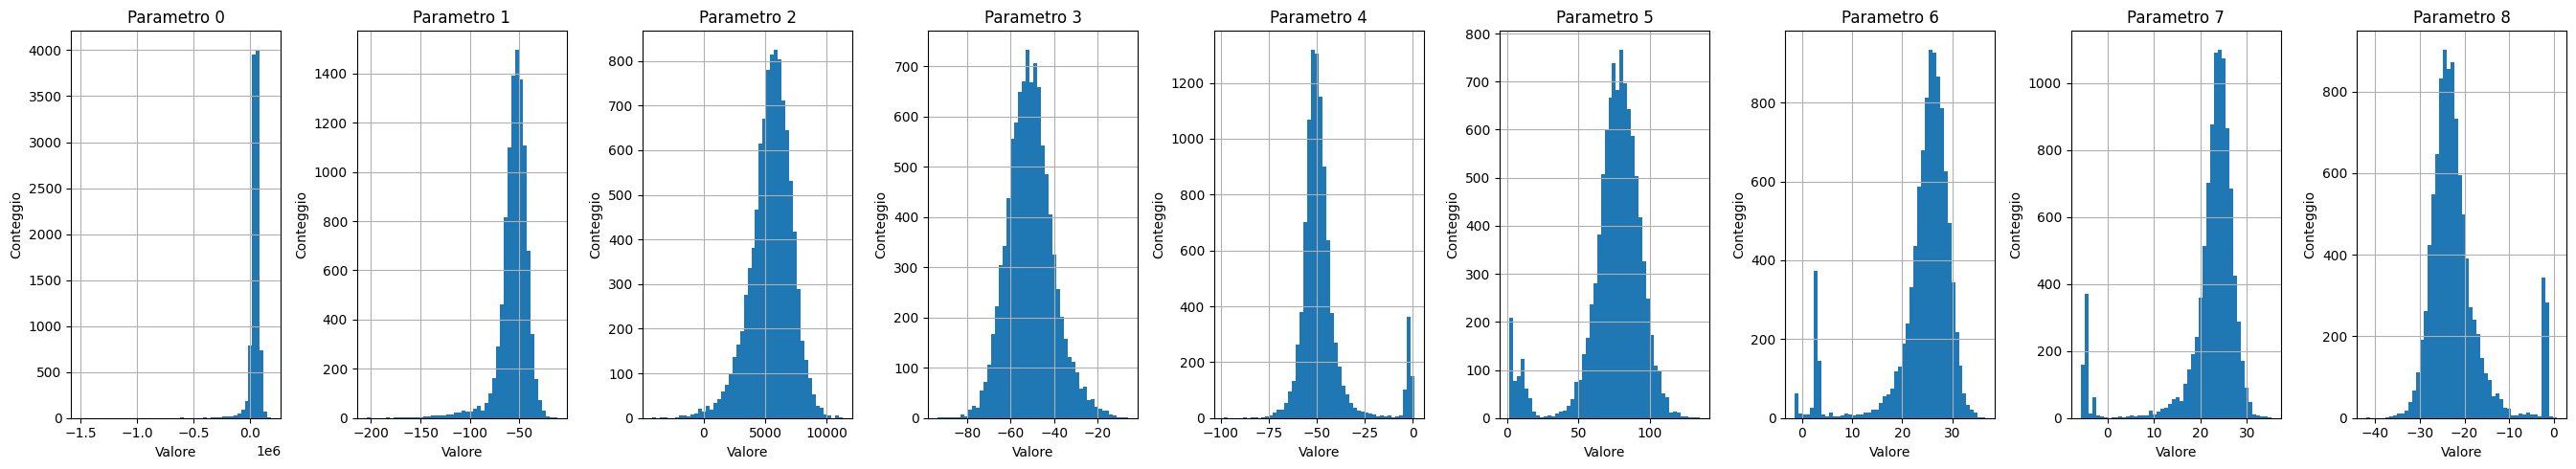

In [556]:

fig, axes = plt.subplots(1, D_PARAMS, figsize=(3*D_PARAMS, 5))

for i, ax in enumerate(axes):
    ax.hist(k_samples[:, i], bins=50)
    ax.set_title(f'Parametro {i}')
    ax.set_xlabel('Valore')
    ax.set_ylabel('Conteggio')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [549]:
print("Esempi di parametri campionati (vettori 9D) con seed diversi:")
for i in range(1, 4):
    print(f"--- Esempio seed{i*111} ---")
    key = jax.random.PRNGKey(i*111)
    key, subkey = jax.random.split(key)
    z = jax.random.normal(subkey, (1, D_PARAMS))
    k_samples, log_det = forward(flow_params, z)
    print(k_samples[0])

    # Esempio di predizione con un singolo campione di parametri
    k_example = k_samples[0]
    pred_example = net(unflatten_params(k_example), X)
    for i, lab in enumerate(labels):
        print(f"  {lab}  →  {pred_example[i,0]:.6f}")


Esempi di parametri campionati (vettori 9D) con seed diversi:
--- Esempio seed111 ---
[10848.711      -53.53932   6593.2793     -51.882687   -58.418873
    79.11669     24.739323    18.54535    -22.008587]
  (0,0)→0  →  0.000000
  (0,1)→1  →  1.000000
  (1,0)→1  →  1.000000
  (1,1)→0  →  0.000000
--- Esempio seed222 ---
[ 2.5054648e+04 -3.1704580e+01  3.6195522e+03 -3.1071373e+01
 -4.9556137e+01  4.7016701e+01  2.4575527e+01  2.3553139e+01
 -1.6935690e+01]
  (0,0)→0  →  0.000000
  (0,1)→1  →  1.000000
  (1,0)→1  →  1.000000
  (1,1)→0  →  0.000000
--- Esempio seed333 ---
[ 3.1794404e+04 -4.2752689e+01  1.9026349e+03 -4.8378143e+01
 -2.9087416e+01  7.0741310e+01  1.8037525e+01  1.6547352e+01
 -2.3010313e+01]
  (0,0)→0  →  0.000000
  (0,1)→1  →  0.999991
  (1,0)→1  →  0.999991
  (1,1)→0  →  0.000000
